# Retail Sales & Customer Analysis

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

## Project Objective
Analyze retail customer and transaction data to understand customer behavior, product performance, store-type performance, and transaction patterns through data cleaning, exploratory data analysis, and visualization.

# Importing all Needed Libraries

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Changing Directory
os.chdir('C:\\Users\\pc\\Desktop\\Case Study 1 - Retail Case Study')

In [3]:
a = pd.read_csv('Customer.csv')

In [4]:
b = pd.read_csv('prod_cat_info.csv')

In [5]:
c = pd.read_csv('Transactions.csv')

In [6]:
a

,customer_Id,DOB,Gender,city_code
0,268408,02-01-1970,M,4.0
1,269696,07-01-1970,F,8.0
2,268159,08-01-1970,F,8.0
3,270181,10-01-1970,F,2.0
4,268073,11-01-1970,M,1.0
...,...,...,...,...
5642,274474,19-12-1992,M,2.0
5643,267666,24-12-1992,M,6.0
5644,270476,25-12-1992,F,3.0
5645,269626,27-12-1992,F,5.0


In [7]:
# merging all tables
cust_final = pd.merge(left = a , right = c , left_on = 'customer_Id' , right_on = 'cust_id' , how = 'inner').merge( b, left_on = 'prod_subcat_code' , right_on = 'prod_sub_cat_code',how = 'inner' )

In [8]:
cust_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57166 entries, 0 to 57165
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_Id        57166 non-null  int64  
 1   DOB                57166 non-null  object 
 2   Gender             57144 non-null  object 
 3   city_code          57151 non-null  float64
 4   transaction_id     57166 non-null  int64  
 5   cust_id            57166 non-null  int64  
 6   tran_date          57166 non-null  object 
 7   prod_subcat_code   57166 non-null  int64  
 8   prod_cat_code_x    57166 non-null  int64  
 9   Qty                57166 non-null  int64  
 10  Rate               57166 non-null  int64  
 11  Tax                57166 non-null  float64
 12  total_amt          57166 non-null  float64
 13  Store_type         57166 non-null  object 
 14  prod_cat_code_y    57166 non-null  int64  
 15  prod_cat           57166 non-null  object 
 16  prod_sub_cat_code  571

In [9]:
cust_final['tran_date'] = pd.to_datetime(cust_final['tran_date'],format = 'mixed',dayfirst = True)


In [10]:
cust_final['DOB'] = pd.to_datetime(cust_final['DOB'],format = 'mixed',dayfirst = True)


In [11]:
# Prepare a summary report for the merged data set .

In [12]:
# a. Get the column names and their corresponding data types.
cust_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57166 entries, 0 to 57165
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_Id        57166 non-null  int64         
 1   DOB                57166 non-null  datetime64[ns]
 2   Gender             57144 non-null  object        
 3   city_code          57151 non-null  float64       
 4   transaction_id     57166 non-null  int64         
 5   cust_id            57166 non-null  int64         
 6   tran_date          57166 non-null  datetime64[ns]
 7   prod_subcat_code   57166 non-null  int64         
 8   prod_cat_code_x    57166 non-null  int64         
 9   Qty                57166 non-null  int64         
 10  Rate               57166 non-null  int64         
 11  Tax                57166 non-null  float64       
 12  total_amt          57166 non-null  float64       
 13  Store_type         57166 non-null  object        
 14  prod_c

In [13]:
cust_final[['city_code','transaction_id','prod_subcat_code','prod_cat_code_x','prod_cat_code_y','prod_subcat','cust_id']] = cust_final[['city_code','transaction_id','prod_subcat_code','prod_cat_code_x','prod_cat_code_y','prod_subcat','cust_id']].astype('object')

In [14]:
# # b. Top 10 observations

In [15]:
cust_final.head(10)

,customer_Id,DOB,Gender,city_code,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code_x,Qty,Rate,Tax,total_amt,Store_type,prod_cat_code_y,prod_cat,prod_sub_cat_code,prod_subcat
0,268408,1970-01-02,M,4.0,87243835584,268408,2014-01-13,7,5,5,187,98.175,1033.175,TeleShop,5,Books,7,Fiction
1,268408,1970-01-02,M,4.0,16197868036,268408,2013-12-16,1,4,-5,-210,110.250,-1160.250,Flagship store,1,Clothing,1,Women
2,268408,1970-01-02,M,4.0,16197868036,268408,2013-12-16,1,4,-5,-210,110.250,-1160.250,Flagship store,2,Footwear,1,Mens
3,268408,1970-01-02,M,4.0,16197868036,268408,2013-12-16,1,4,-5,-210,110.250,-1160.250,Flagship store,4,Bags,1,Mens
4,268408,1970-01-02,M,4.0,16197868036,268408,2013-12-12,1,4,5,210,110.250,1160.250,Flagship store,1,Clothing,1,Women
5,268408,1970-01-02,M,4.0,16197868036,268408,2013-12-12,1,4,5,210,110.250,1160.250,Flagship store,2,Footwear,1,Mens
6,268408,1970-01-02,M,4.0,16197868036,268408,2013-12-12,1,4,5,210,110.250,1160.250,Flagship store,4,Bags,1,Mens
7,268408,1970-01-02,M,4.0,28810141075,268408,2013-09-02,10,6,2,813,170.730,1796.730,TeleShop,3,Electronics,10,Audio and video
8,268408,1970-01-02,M,4.0,28810141075,268408,2013-09-02,10,6,2,813,170.730,1796.730,TeleShop,5,Books,10,Non-Fiction
9,268408,1970-01-02,M,4.0,28810141075,268408,2013-09-02,10,6,2,813,170.730,1796.730,TeleShop,6,Home and kitchen,10,Kitchen


In [16]:
#bottom 10
cust_final.tail(10)

,customer_Id,DOB,Gender,city_code,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code_x,Qty,Rate,Tax,total_amt,Store_type,prod_cat_code_y,prod_cat,prod_sub_cat_code,prod_subcat
57156,269626,1992-12-27,F,5.0,94134051896,269626,2011-07-07,3,1,3,1078,339.57,3573.57,MBR,2,Footwear,3,Women
57157,269626,1992-12-27,F,5.0,94134051896,269626,2011-07-07,3,1,3,1078,339.57,3573.57,MBR,5,Books,3,Comics
57158,274308,1992-12-29,F,5.0,26208690928,274308,2012-10-22,1,2,2,898,188.58,1984.58,MBR,1,Clothing,1,Women
57159,274308,1992-12-29,F,5.0,26208690928,274308,2012-10-22,1,2,2,898,188.58,1984.58,MBR,2,Footwear,1,Mens
57160,274308,1992-12-29,F,5.0,26208690928,274308,2012-10-22,1,2,2,898,188.58,1984.58,MBR,4,Bags,1,Mens
57161,274308,1992-12-29,F,5.0,57358822237,274308,2012-09-05,1,2,4,876,367.92,3871.92,e-Shop,1,Clothing,1,Women
57162,274308,1992-12-29,F,5.0,57358822237,274308,2012-09-05,1,2,4,876,367.92,3871.92,e-Shop,2,Footwear,1,Mens
57163,274308,1992-12-29,F,5.0,57358822237,274308,2012-09-05,1,2,4,876,367.92,3871.92,e-Shop,4,Bags,1,Mens
57164,274308,1992-12-29,F,5.0,58160544337,274308,2012-07-04,12,5,5,588,308.70,3248.70,e-Shop,5,Books,12,Academic
57165,274308,1992-12-29,F,5.0,58160544337,274308,2012-07-04,12,5,5,588,308.70,3248.70,e-Shop,6,Home and kitchen,12,Tools


In [17]:
cont_cust = cust_final.select_dtypes(['int','float'])

In [18]:
# c. “Five-number summary” for continuous variables (min, Q1, median, Q3 and max)
cont_cust.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_Id,57166.0,271015.375101,2426.954106,266783.000,268931.00,270982.0000,273096.00,275265.0
Qty,57166.0,2.429766,2.273219,-5.000,1.00,3.0000,4.00,5.0
Rate,57166.0,635.022653,623.390431,-1499.000,312.00,709.0000,1109.00,1500.0
Tax,57166.0,248.967409,187.344788,7.350,98.49,199.3425,364.98,787.5
total_amt,57166.0,2102.084532,2516.597510,-8270.925,764.66,1759.1600,3553.68,8287.5
prod_sub_cat_code,57166.0,5.613949,3.701183,1.000,3.00,4.0000,10.00,12.0


In [19]:
# d. Frequency tables for all the categorical variables

In [20]:
cat_cust = cust_final.select_dtypes(include = 'object')
for i in cat_cust:
    print((cat_cust[i].value_counts()))
    print('\n')

Gender
M    29191
F    27953
Name: count, dtype: int64


city_code
4.0     5961
5.0     5941
3.0     5886
10.0    5800
8.0     5771
7.0     5761
2.0     5616
1.0     5582
9.0     5538
6.0     5295
Name: count, dtype: int64


transaction_id
32263938079    16
78775295433    12
48727689115    12
93438842631    12
4545655117     12
               ..
98973820527     1
21663198292     1
13335198152     1
50019198822     1
87243835584     1
Name: count, Length: 20878, dtype: int64


cust_id
269245    36
271797    35
267801    35
275252    34
271834    34
          ..
266803     1
273332     1
269944     1
272539     1
266804     1
Name: count, Length: 5506, dtype: int64


prod_subcat_code
4     16008
3      9201
10     8979
1      8850
11     4116
12     4058
7      1043
2      1007
6       989
9       985
8       972
5       958
Name: count, dtype: int64


prod_cat_code_x
5    12141
2    10006
3     9895
1     9847
6     8288
4     6989
Name: count, dtype: int64


Store_type
e-Shop          

In [21]:
# 3. Generate histograms for all continuous variables and frequency bars for categorical variables

In [22]:
cont_cust = cust_final.select_dtypes(include = 'number')

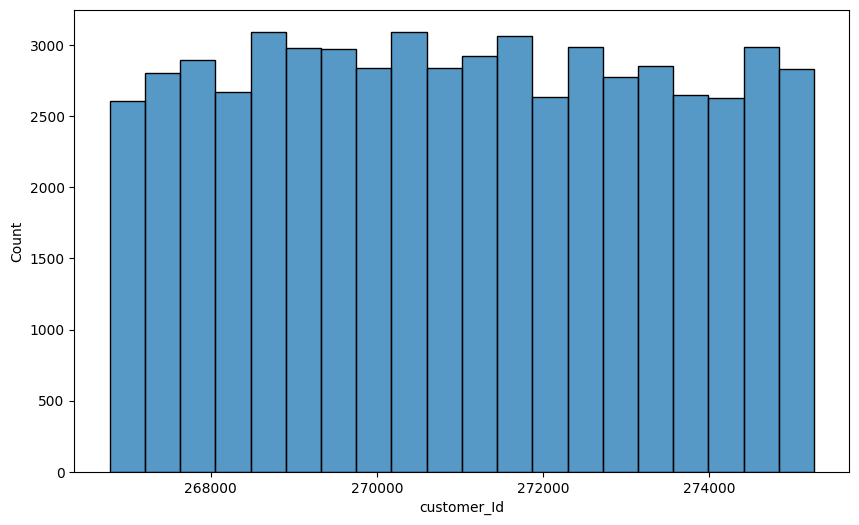

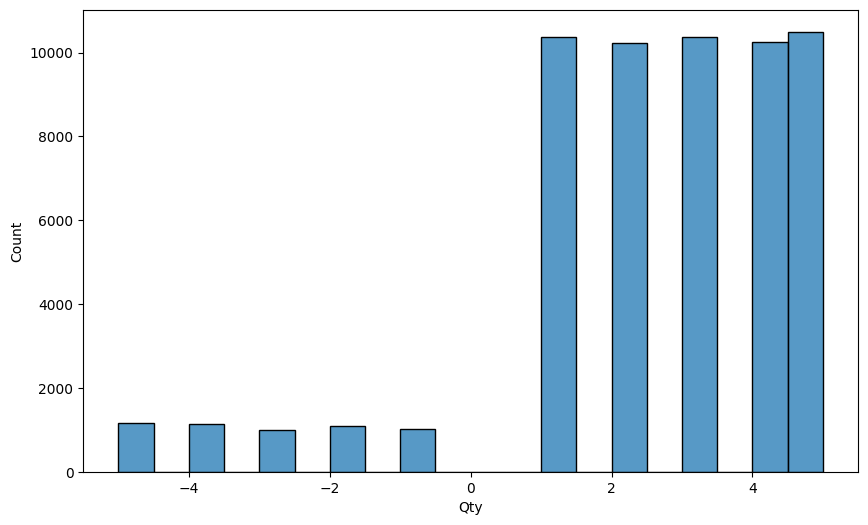

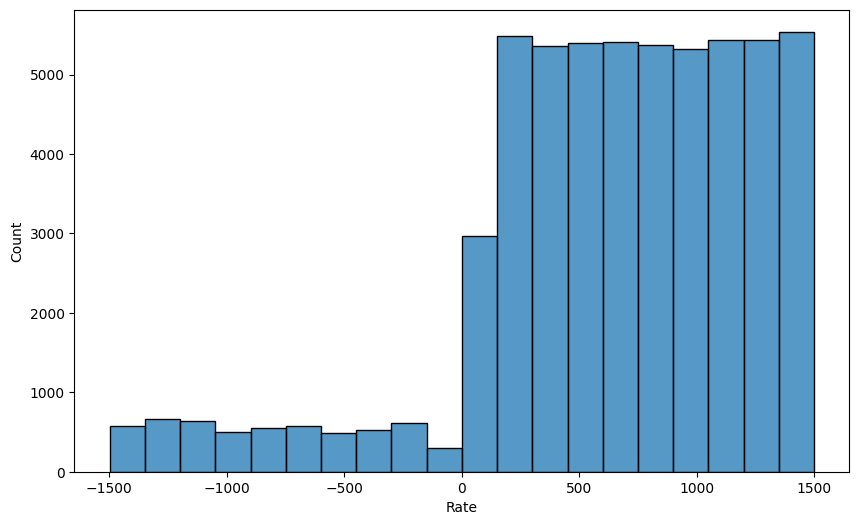

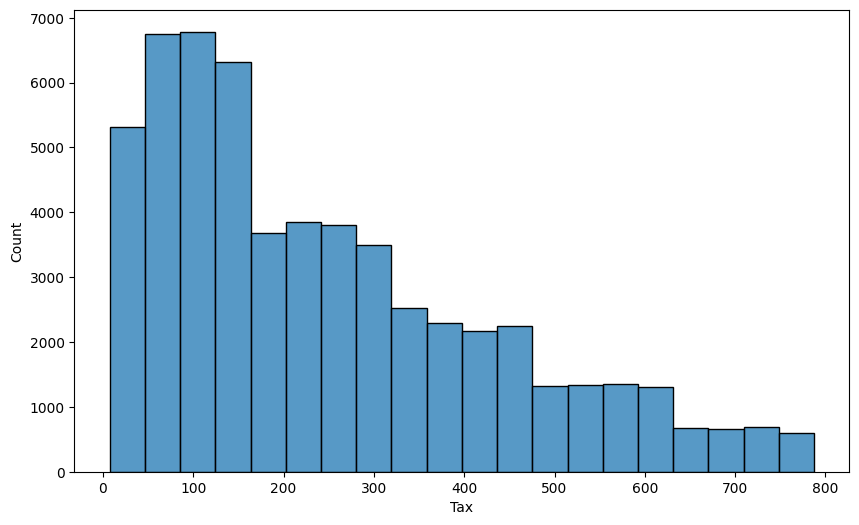

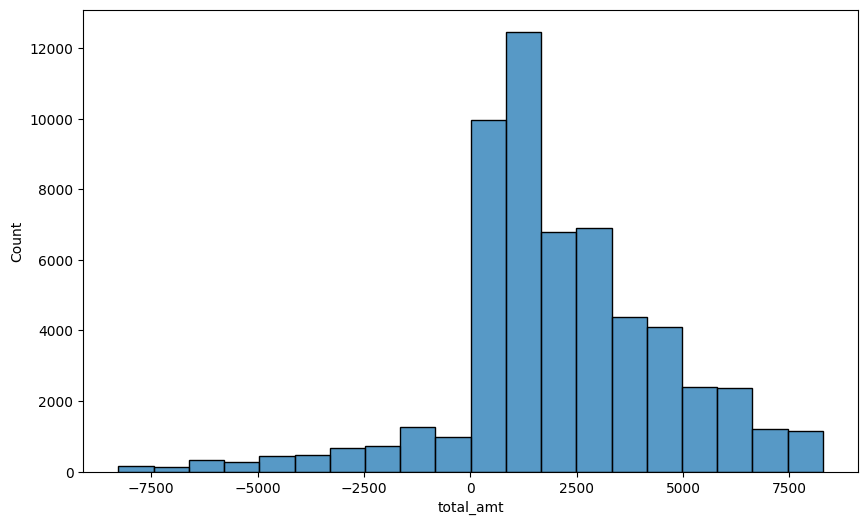

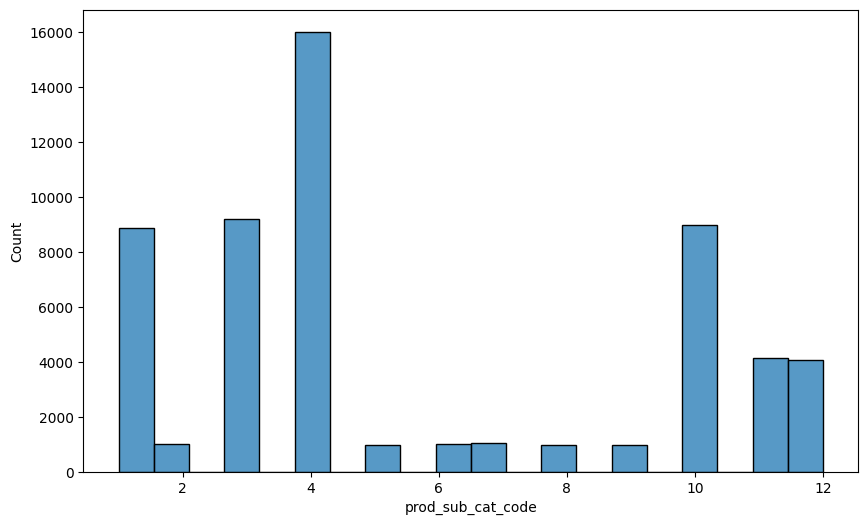

In [23]:
# Generate histograms for all continuous variables
for i in cont_cust:
    plt.figure(figsize=(10, 6))
    sns.histplot(data = cont_cust , x = i,bins = 20)
    plt.show() 

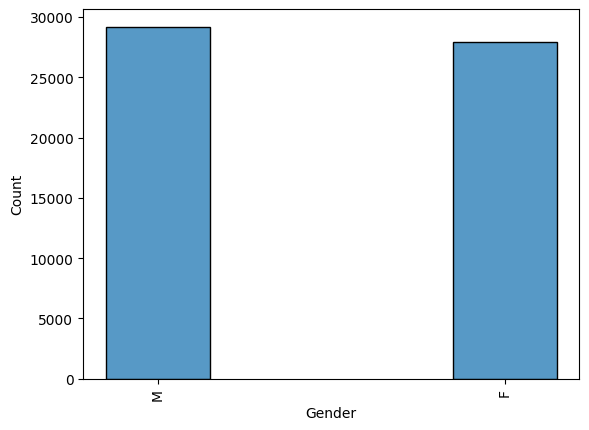

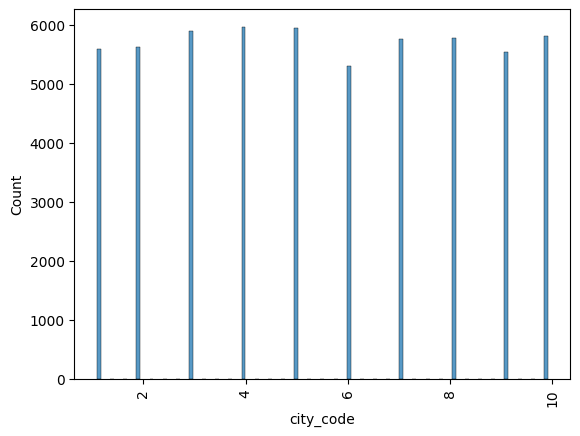

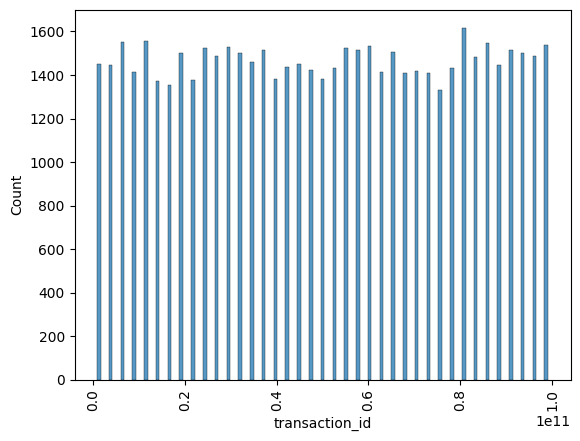

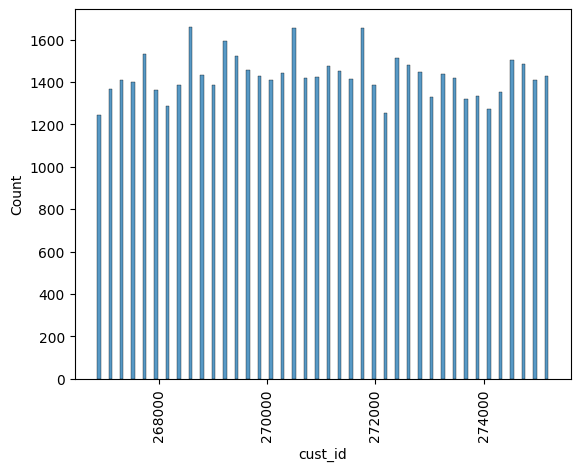

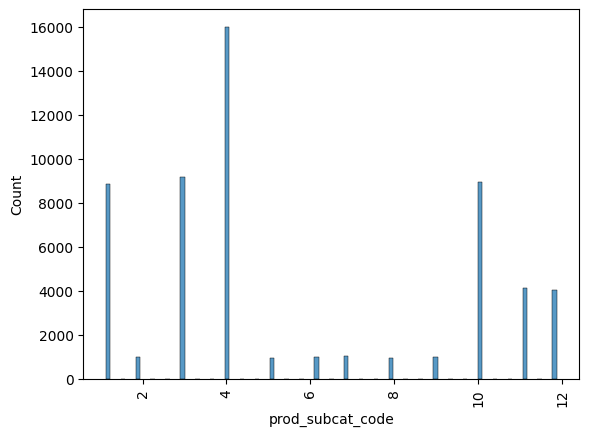

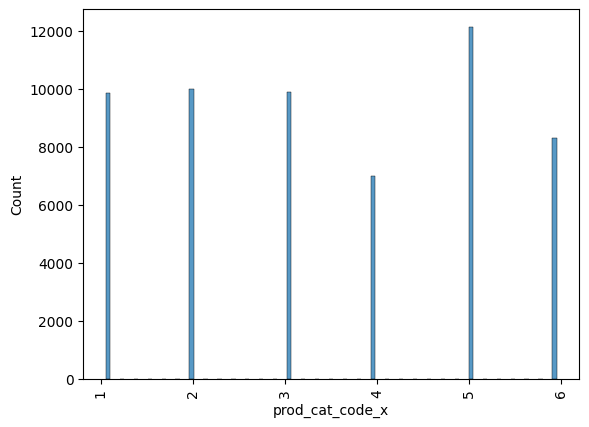

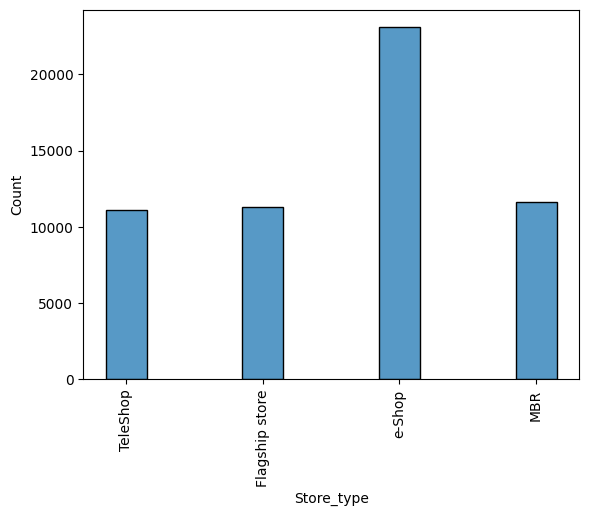

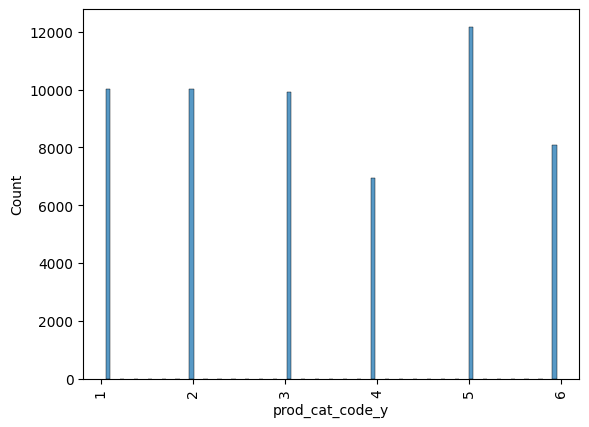

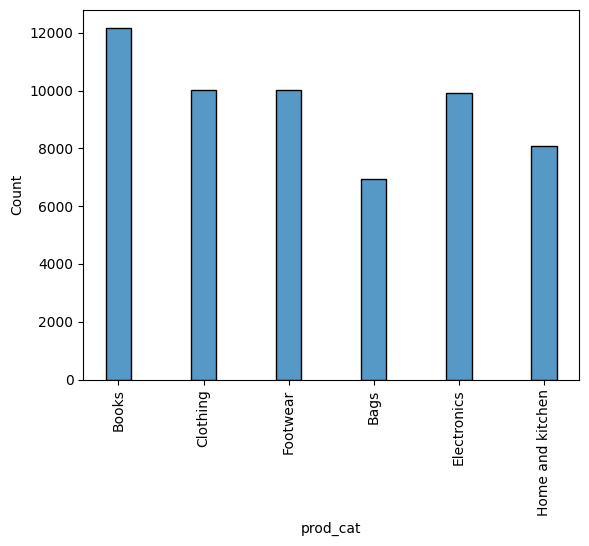

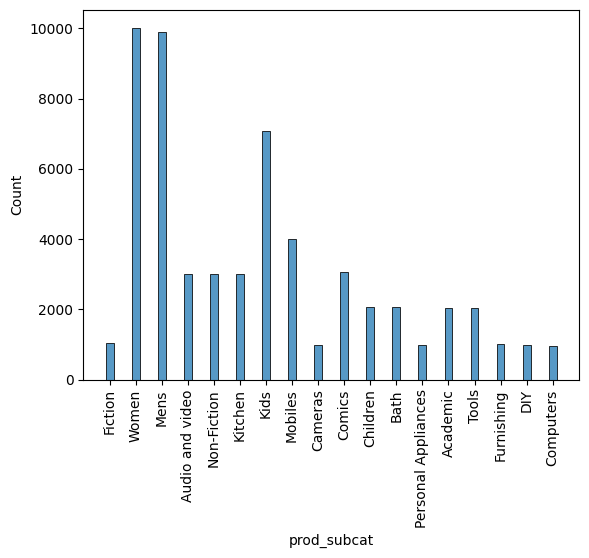

In [24]:
# frequency bars for categorical variables
for i in cat_cust:
    sns.histplot(data = cat_cust , x = i,shrink = 0.3)
    plt.xticks(rotation=90)
    plt.show()

In [25]:
cust_final

,customer_Id,DOB,Gender,city_code,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code_x,Qty,Rate,Tax,total_amt,Store_type,prod_cat_code_y,prod_cat,prod_sub_cat_code,prod_subcat
0,268408,1970-01-02,M,4.0,87243835584,268408,2014-01-13,7,5,5,187,98.175,1033.175,TeleShop,5,Books,7,Fiction
1,268408,1970-01-02,M,4.0,16197868036,268408,2013-12-16,1,4,-5,-210,110.250,-1160.250,Flagship store,1,Clothing,1,Women
2,268408,1970-01-02,M,4.0,16197868036,268408,2013-12-16,1,4,-5,-210,110.250,-1160.250,Flagship store,2,Footwear,1,Mens
3,268408,1970-01-02,M,4.0,16197868036,268408,2013-12-16,1,4,-5,-210,110.250,-1160.250,Flagship store,4,Bags,1,Mens
4,268408,1970-01-02,M,4.0,16197868036,268408,2013-12-12,1,4,5,210,110.250,1160.250,Flagship store,1,Clothing,1,Women
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57161,274308,1992-12-29,F,5.0,57358822237,274308,2012-09-05,1,2,4,876,367.920,3871.920,e-Shop,1,Clothing,1,Women
57162,274308,1992-12-29,F,5.0,57358822237,274308,2012-09-05,1,2,4,876,367.920,3871.920,e-Shop,2,Footwear,1,Mens
57163,274308,1992-12-29,F,5.0,57358822237,274308,2012-09-05,1,2,4,876,367.920,3871.920,e-Shop,4,Bags,1,Mens
57164,274308,1992-12-29,F,5.0,58160544337,274308,2012-07-04,12,5,5,588,308.700,3248.700,e-Shop,5,Books,12,Academic


In [26]:
# 4. Calculate the following information using the merged dataset :
# a. Time period of the available transaction data
# b. Count of transactions where the total amount of transaction was negative

In [27]:
# a. Time period of the available transaction data
print('First Date',cust_final['tran_date'].min().date(),'\nLast Date' ,cust_final['tran_date'].max().date())


First Date 2011-01-25 
Last Date 2014-02-28


In [28]:
# b. Count of transactions where the total amount of transaction was negative
print(np.where(cust_final['total_amt']<0,1,0).sum())

5430


In [29]:
# 5. Analyze which product categories are more popular among females vs male customers.
pd.crosstab(cust_final['Gender'], cust_final['prod_cat']).T.sort_values(by='M', ascending=False)


Gender,F,M
prod_cat,,
Books,6004,6169
Electronics,4795,5113
Clothing,4916,5099
Footwear,4916,5099
Home and kitchen,3959,4125
Bags,3363,3586


In [30]:
cust_final.head()

,customer_Id,DOB,Gender,city_code,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code_x,Qty,Rate,Tax,total_amt,Store_type,prod_cat_code_y,prod_cat,prod_sub_cat_code,prod_subcat
0,268408,1970-01-02,M,4.0,87243835584,268408,2014-01-13,7,5,5,187,98.175,1033.175,TeleShop,5,Books,7,Fiction
1,268408,1970-01-02,M,4.0,16197868036,268408,2013-12-16,1,4,-5,-210,110.250,-1160.250,Flagship store,1,Clothing,1,Women
2,268408,1970-01-02,M,4.0,16197868036,268408,2013-12-16,1,4,-5,-210,110.250,-1160.250,Flagship store,2,Footwear,1,Mens
3,268408,1970-01-02,M,4.0,16197868036,268408,2013-12-16,1,4,-5,-210,110.250,-1160.250,Flagship store,4,Bags,1,Mens
4,268408,1970-01-02,M,4.0,16197868036,268408,2013-12-12,1,4,5,210,110.250,1160.250,Flagship store,1,Clothing,1,Women


In [31]:
# 6. Which City code has the maximum customers and what was the percentage of customers from that city?
count = cust_final.groupby('city_code')['cust_id'].nunique().reset_index().sort_values(by = 'cust_id',ascending = False)
count['Perc_count'] = (count['cust_id']/count['cust_id'].sum())*100

In [32]:
count.head(1)

,city_code,cust_id,Perc_count
2,3.0,576,10.465116


In [33]:
# 7. Which store type sells the maximum products by value and by quantity?
cust_final.groupby('Store_type')[['total_amt','Qty']].sum().sort_values(by=['total_amt','Qty'],ascending = False)
# e-shop Sells the maximum product and earn maximum.

,total_amt,Qty
Store_type,,
e-Shop,49096588.71,56372
Flagship store,24072659.26,27600
MBR,24018167.29,27869
TeleShop,22980349.08,27059


In [34]:
# 8. What was the total amount earned from the "Electronics" and "Clothing" categories from Flagship Stores?
print(int(cust_final[(cust_final['prod_cat'].isin(['Electronics','Clothing'])) & (cust_final['Store_type']=='Flagship store')]['total_amt'].sum()))
# 8526843 is the total amount

8526843


In [35]:
cust_final.head(10)

,customer_Id,DOB,Gender,city_code,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code_x,Qty,Rate,Tax,total_amt,Store_type,prod_cat_code_y,prod_cat,prod_sub_cat_code,prod_subcat
0,268408,1970-01-02,M,4.0,87243835584,268408,2014-01-13,7,5,5,187,98.175,1033.175,TeleShop,5,Books,7,Fiction
1,268408,1970-01-02,M,4.0,16197868036,268408,2013-12-16,1,4,-5,-210,110.250,-1160.250,Flagship store,1,Clothing,1,Women
2,268408,1970-01-02,M,4.0,16197868036,268408,2013-12-16,1,4,-5,-210,110.250,-1160.250,Flagship store,2,Footwear,1,Mens
3,268408,1970-01-02,M,4.0,16197868036,268408,2013-12-16,1,4,-5,-210,110.250,-1160.250,Flagship store,4,Bags,1,Mens
4,268408,1970-01-02,M,4.0,16197868036,268408,2013-12-12,1,4,5,210,110.250,1160.250,Flagship store,1,Clothing,1,Women
5,268408,1970-01-02,M,4.0,16197868036,268408,2013-12-12,1,4,5,210,110.250,1160.250,Flagship store,2,Footwear,1,Mens
6,268408,1970-01-02,M,4.0,16197868036,268408,2013-12-12,1,4,5,210,110.250,1160.250,Flagship store,4,Bags,1,Mens
7,268408,1970-01-02,M,4.0,28810141075,268408,2013-09-02,10,6,2,813,170.730,1796.730,TeleShop,3,Electronics,10,Audio and video
8,268408,1970-01-02,M,4.0,28810141075,268408,2013-09-02,10,6,2,813,170.730,1796.730,TeleShop,5,Books,10,Non-Fiction
9,268408,1970-01-02,M,4.0,28810141075,268408,2013-09-02,10,6,2,813,170.730,1796.730,TeleShop,6,Home and kitchen,10,Kitchen


In [36]:
# 9. What was the total amount earned from "Male" customers under the "Electronics" category?
print(int(cust_final[(cust_final['Gender']=='M') & (cust_final['prod_cat']=='Electronics')]['total_amt'].sum()))
# 10947130 is the total amount


10947130


In [37]:
clean_data = cust_final[cust_final['total_amt'] >= 0]

In [38]:
# 10. How many customers have more than 10 unique transactions, after removing all transactions which have any negative amounts?
print((clean_data.groupby('customer_Id')['transaction_id'].nunique() > 10).sum())

6


In [39]:
# 11. For all customers aged between 25 - 35, find out:
#  a. What was the total amount spent for “Electronics” and “Books” product categories?

In [40]:
cust_final['Age'] = ((pd.Timestamp.today()- cust_final['DOB']).dt.days // 365)


In [41]:
ad_amt = cust_final[(cust_final['Age'].between(25,35) & (cust_final['prod_cat'].isin(['Electronics','Books'])))]
print(int(ad_amt['total_amt'].sum()))

4394383


In [42]:

# 11. For all customers aged between 25 - 35, find out:
# b. What was the total amount spent by these customers between 1st Jan, 2014 to 1st Mar, 2014?

In [43]:
print(cust_final[(cust_final['Age'].between(25,35)) & (cust_final['tran_date'].between('2014-01-01','2014-03-01'))]['total_amt'].sum())

605416.24


## Key Takeaways

- The analysis combines customer, transaction, and product-category information to explore retail performance from multiple perspectives.
- Store type, product category, customer demographics, city, and transaction behavior provide useful dimensions for understanding sales patterns.
- Visual exploration helps identify differences in customer distribution, category performance, and transaction activity.

## Conclusion

This project demonstrates an end-to-end Python-based exploratory data analysis workflow, from data preparation and integration to business-focused analysis and visualization.